# WEEK 2 of the Capstone Project

## WEEK 2 AIM
- Sanity check the previous week outputs visually
- Get a simple Bayesian Optimisation model fit for ALL functions (GP + UCB)
- It should have a simple Gaussian Process surrogate
- A simple acquisition function
- Use the same BO for all functions
- Sanity check the outputs visually.


### STEP 0 - IMPORT RELEVANT PACKAGES


In [67]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Import utility functions
from data_utils import (
    load_initial_data,
    load_week1_data,
    combine_data,
    plot_2d_scatter_with_distribution,
    plot_3d_scatter_with_distribution,
    plot_tsne_with_distribution,
    plot_bo_visualization_2d,
    plot_function_summary_subplot
)


ImportError: cannot import name 'plot_function_summary_subplot' from 'data_utils' (/Users/jackdunning/Documents/Github/Capstone-Project-Imperial-College-London/data_utils.py)

### STEP 1 - DOWNLOAD THE INITIAL DATA


In [ ]:
# Load initial data using utility function
base_dir = Path('/Users/jackdunning/Documents/Github/Capstone-Project-Imperial-College-London/data/initial_data')
initial_data = load_initial_data(base_dir)

print(f"Loaded initial data for {len(initial_data)} functions")
for function_name, data in initial_data.items():
    print(f"  {function_name}: {data['inputs'].shape[0]} samples, {data['inputs'].shape[1]} dimensions")


Loaded initial data for 8 functions
  function_1: 10 samples, 2 dimensions
  function_2: 10 samples, 2 dimensions
  function_3: 15 samples, 3 dimensions
  function_4: 30 samples, 4 dimensions
  function_5: 20 samples, 4 dimensions
  function_6: 20 samples, 5 dimensions
  function_7: 30 samples, 6 dimensions
  function_8: 40 samples, 8 dimensions


### STEP 2 - DOWNLOAD THE WEEK 1 DATA
- 

In [ ]:
# Load week1 data using utility function
week1_dir = Path('/Users/jackdunning/Documents/Github/Capstone-Project-Imperial-College-London/data/week1')
week1_data = load_week1_data(week1_dir)

print(f"Loaded week1 data for {len(week1_data)} functions")
for function_name, data in week1_data.items():
    print(f"  {function_name}: Input shape = {data['input'].shape}, Output = {data['output']}")


Loaded week1 data for 8 functions
  function_1: Input shape = (2,), Output = 2.6752879910742468e-09
  function_2: Input shape = (2,), Output = 0.42721035515778233
  function_3: Input shape = (3,), Output = -0.45300818056360315
  function_4: Input shape = (4,), Output = -25.81769735182645
  function_5: Input shape = (4,), Output = 4219.157963029058
  function_6: Input shape = (5,), Output = -2.6736180536592746
  function_7: Input shape = (6,), Output = 0.013680510023283559
  function_8: Input shape = (8,), Output = 6.0739207860211


### FUNCTION 1 - COMBINED DATA AND VISUALISATION


In [ ]:
# Function 1 - Combine original data with week 1 data
function_name = 'function_1'

# Get original inputs and outputs
original_inputs = initial_data[function_name]['inputs']
original_outputs = initial_data[function_name]['outputs']

# Get week 1 new input and output
new_input = week1_data[function_name]['input']
new_output = week1_data[function_name]['output']

# Combine inputs: original + new (reshape new_input to be a row vector)
combined_inputs = np.vstack([original_inputs, new_input.reshape(1, -1)])

# Combine outputs: original + new
combined_outputs = np.concatenate([original_outputs, np.array([new_output])])

print("=" * 60)
print(f"FUNCTION 1 - COMBINED DATA")
print("=" * 60)
print(f"\nOriginal inputs shape: {original_inputs.shape}")
print(f"Original inputs:\n{original_inputs}")
print(f"\nNew input from week 1: {new_input}")
print(f"\nCombined inputs shape: {combined_inputs.shape}")
print(f"Combined inputs:\n{combined_inputs}")
print(f"\n" + "-" * 60)
print(f"\nOriginal outputs shape: {original_outputs.shape}")
print(f"Original outputs:\n{original_outputs}")
print(f"\nNew output from week 1: {new_output}")
print(f"\nCombined outputs shape: {combined_outputs.shape}")
print(f"Combined outputs:\n{combined_outputs}")
print("=" * 60)


FUNCTION 1 - COMBINED DATA

Original inputs shape: (10, 2)
Original inputs:
[[0.31940389 0.76295937]
 [0.57432921 0.8798981 ]
 [0.73102363 0.73299988]
 [0.84035342 0.26473161]
 [0.65011406 0.68152635]
 [0.41043714 0.1475543 ]
 [0.31269116 0.07872278]
 [0.68341817 0.86105746]
 [0.08250725 0.40348751]
 [0.88388983 0.58225397]]

New input from week 1: [0.5 0.5]

Combined inputs shape: (11, 2)
Combined inputs:
[[0.31940389 0.76295937]
 [0.57432921 0.8798981 ]
 [0.73102363 0.73299988]
 [0.84035342 0.26473161]
 [0.65011406 0.68152635]
 [0.41043714 0.1475543 ]
 [0.31269116 0.07872278]
 [0.68341817 0.86105746]
 [0.08250725 0.40348751]
 [0.88388983 0.58225397]
 [0.5        0.5       ]]

------------------------------------------------------------

Original outputs shape: (10,)
Original outputs:
[ 1.32267704e-079  1.03307824e-046  7.71087511e-016  3.34177101e-124
 -3.60606264e-003 -2.15924904e-054 -2.08909327e-091  2.53500115e-040
  3.60677119e-081  6.22985647e-048]

New output from week 1: 2.67

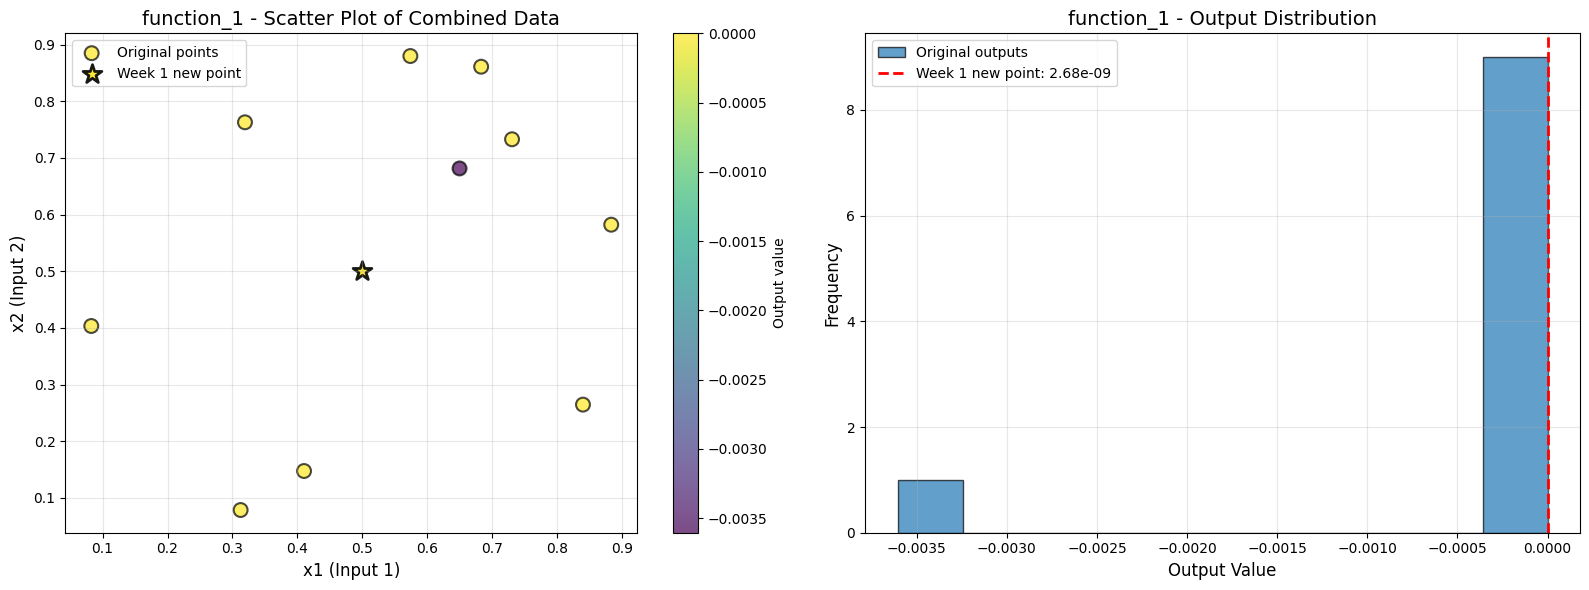


Combined inputs shape: (11, 2)
Combined outputs shape: (11,)


In [ ]:
# Function 1 - Visualization using utility function
function_name = 'function_1'
original_inputs = initial_data[function_name]['inputs']
original_outputs = initial_data[function_name]['outputs']
new_input = week1_data[function_name]['input']
new_output = week1_data[function_name]['output']

# Use utility function for visualization
plot_2d_scatter_with_distribution(
    original_inputs, original_outputs, 
    new_input, new_output, 
    function_name
)

# Print combined data info
combined_inputs, combined_outputs = combine_data(
    original_inputs, original_outputs, new_input, new_output
)
print(f"\nCombined inputs shape: {combined_inputs.shape}")
print(f"Combined outputs shape: {combined_outputs.shape}")


### FUNCTION 2 - COMBINED DATA AND VISUALISATION


In [ ]:
# Function 2 - Combine original data with week 1 data
function_name = 'function_2'

# Get original inputs and outputs
original_inputs = initial_data[function_name]['inputs']
original_outputs = initial_data[function_name]['outputs']

# Get week 1 new input and output
new_input = week1_data[function_name]['input']
new_output = week1_data[function_name]['output']

# Combine inputs: original + new (reshape new_input to be a row vector)
combined_inputs = np.vstack([original_inputs, new_input.reshape(1, -1)])

# Combine outputs: original + new
combined_outputs = np.concatenate([original_outputs, np.array([new_output])])

print("=" * 60)
print(f"FUNCTION 2 - COMBINED DATA")
print("=" * 60)
print(f"\nOriginal inputs shape: {original_inputs.shape}")
print(f"Original inputs:\n{original_inputs}")
print(f"\nNew input from week 1: {new_input}")
print(f"\nCombined inputs shape: {combined_inputs.shape}")
print(f"Combined inputs:\n{combined_inputs}")
print(f"\n" + "-" * 60)
print(f"\nOriginal outputs shape: {original_outputs.shape}")
print(f"Original outputs:\n{original_outputs}")
print(f"\nNew output from week 1: {new_output}")
print(f"\nCombined outputs shape: {combined_outputs.shape}")
print(f"Combined outputs:\n{combined_outputs}")
print("=" * 60)


FUNCTION 2 - COMBINED DATA

Original inputs shape: (10, 2)
Original inputs:
[[0.66579958 0.12396913]
 [0.87779099 0.7786275 ]
 [0.14269907 0.34900513]
 [0.84527543 0.71112027]
 [0.45464714 0.29045518]
 [0.57771284 0.77197318]
 [0.43816606 0.68501826]
 [0.34174959 0.02869772]
 [0.33864816 0.21386725]
 [0.70263656 0.9265642 ]]

New input from week 1: [0.65 0.5 ]

Combined inputs shape: (11, 2)
Combined inputs:
[[0.66579958 0.12396913]
 [0.87779099 0.7786275 ]
 [0.14269907 0.34900513]
 [0.84527543 0.71112027]
 [0.45464714 0.29045518]
 [0.57771284 0.77197318]
 [0.43816606 0.68501826]
 [0.34174959 0.02869772]
 [0.33864816 0.21386725]
 [0.70263656 0.9265642 ]
 [0.65       0.5       ]]

------------------------------------------------------------

Original outputs shape: (10,)
Original outputs:
[ 0.53899612  0.42058624 -0.06562362  0.29399291  0.21496451  0.02310555
  0.24461934  0.03874902 -0.01385762  0.61120522]

New output from week 1: 0.42721035515778233

Combined outputs shape: (11,)
Co

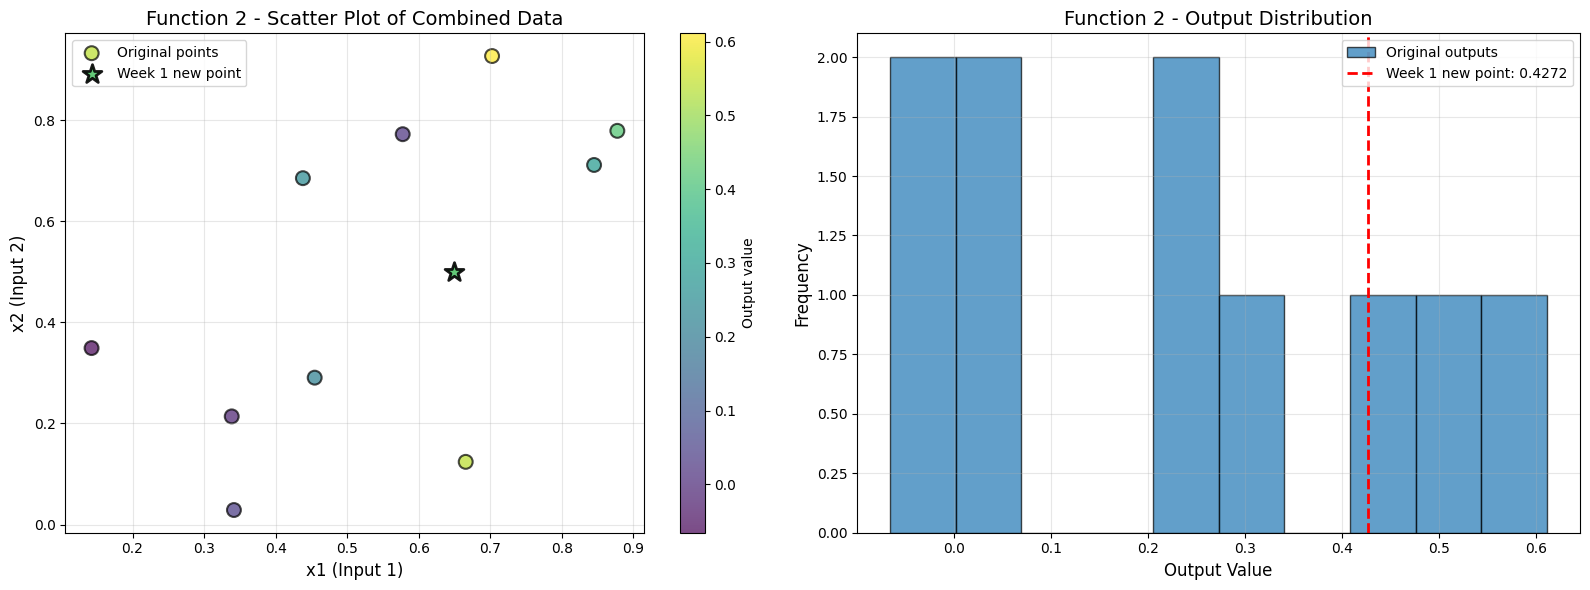


Combined inputs shape: (11, 2)
Combined outputs shape: (11,)


In [ ]:
# Function 2 - Visualization using utility function
function_name = 'function_2'
original_inputs = initial_data[function_name]['inputs']
original_outputs = initial_data[function_name]['outputs']
new_input = week1_data[function_name]['input']
new_output = week1_data[function_name]['output']

# Use utility function for visualization
plot_2d_scatter_with_distribution(
    original_inputs, original_outputs, 
    new_input, new_output, 
    function_name
)

# Print combined data info
combined_inputs, combined_outputs = combine_data(
    original_inputs, original_outputs, new_input, new_output
)
print(f"\nCombined inputs shape: {combined_inputs.shape}")
print(f"Combined outputs shape: {combined_outputs.shape}")


### FUNCTION 3 - COMBINED DATA AND VISUALISATION


In [ ]:
# Function 3 - Combine original data with week 1 data
function_name = 'function_3'

# Get original inputs and outputs
original_inputs = initial_data[function_name]['inputs']
original_outputs = initial_data[function_name]['outputs']

# Get week 1 new input and output
new_input = week1_data[function_name]['input']
new_output = week1_data[function_name]['output']

# Combine inputs: original + new (reshape new_input to be a row vector)
combined_inputs = np.vstack([original_inputs, new_input.reshape(1, -1)])

# Combine outputs: original + new
combined_outputs = np.concatenate([original_outputs, np.array([new_output])])

print("=" * 60)
print(f"FUNCTION 3 - COMBINED DATA")
print("=" * 60)
print(f"\nOriginal inputs shape: {original_inputs.shape}")
print(f"Original inputs:\n{original_inputs}")
print(f"\nNew input from week 1: {new_input}")
print(f"\nCombined inputs shape: {combined_inputs.shape}")
print(f"Combined inputs:\n{combined_inputs}")
print(f"\n" + "-" * 60)
print(f"\nOriginal outputs shape: {original_outputs.shape}")
print(f"Original outputs:\n{original_outputs}")
print(f"\nNew output from week 1: {new_output}")
print(f"\nCombined outputs shape: {combined_outputs.shape}")
print(f"Combined outputs:\n{combined_outputs}")
print("=" * 60)


FUNCTION 3 - COMBINED DATA

Original inputs shape: (15, 3)
Original inputs:
[[0.17152521 0.34391687 0.2487372 ]
 [0.24211446 0.64407427 0.27243281]
 [0.53490572 0.39850092 0.17338873]
 [0.49258141 0.61159319 0.34017639]
 [0.13462167 0.21991724 0.45820622]
 [0.34552327 0.94135983 0.26936348]
 [0.15183663 0.43999062 0.99088187]
 [0.64550284 0.39714294 0.91977134]
 [0.74691195 0.28419631 0.22629985]
 [0.17047699 0.6970324  0.14916943]
 [0.22054934 0.29782524 0.34355534]
 [0.66601366 0.67198515 0.2462953 ]
 [0.04680895 0.23136024 0.77061759]
 [0.60009728 0.72513573 0.06608864]
 [0.96599485 0.86111969 0.56682913]]

New input from week 1: [0.466753 0.990442 0.996265]

Combined inputs shape: (16, 3)
Combined inputs:
[[0.17152521 0.34391687 0.2487372 ]
 [0.24211446 0.64407427 0.27243281]
 [0.53490572 0.39850092 0.17338873]
 [0.49258141 0.61159319 0.34017639]
 [0.13462167 0.21991724 0.45820622]
 [0.34552327 0.94135983 0.26936348]
 [0.15183663 0.43999062 0.99088187]
 [0.64550284 0.39714294 0.919

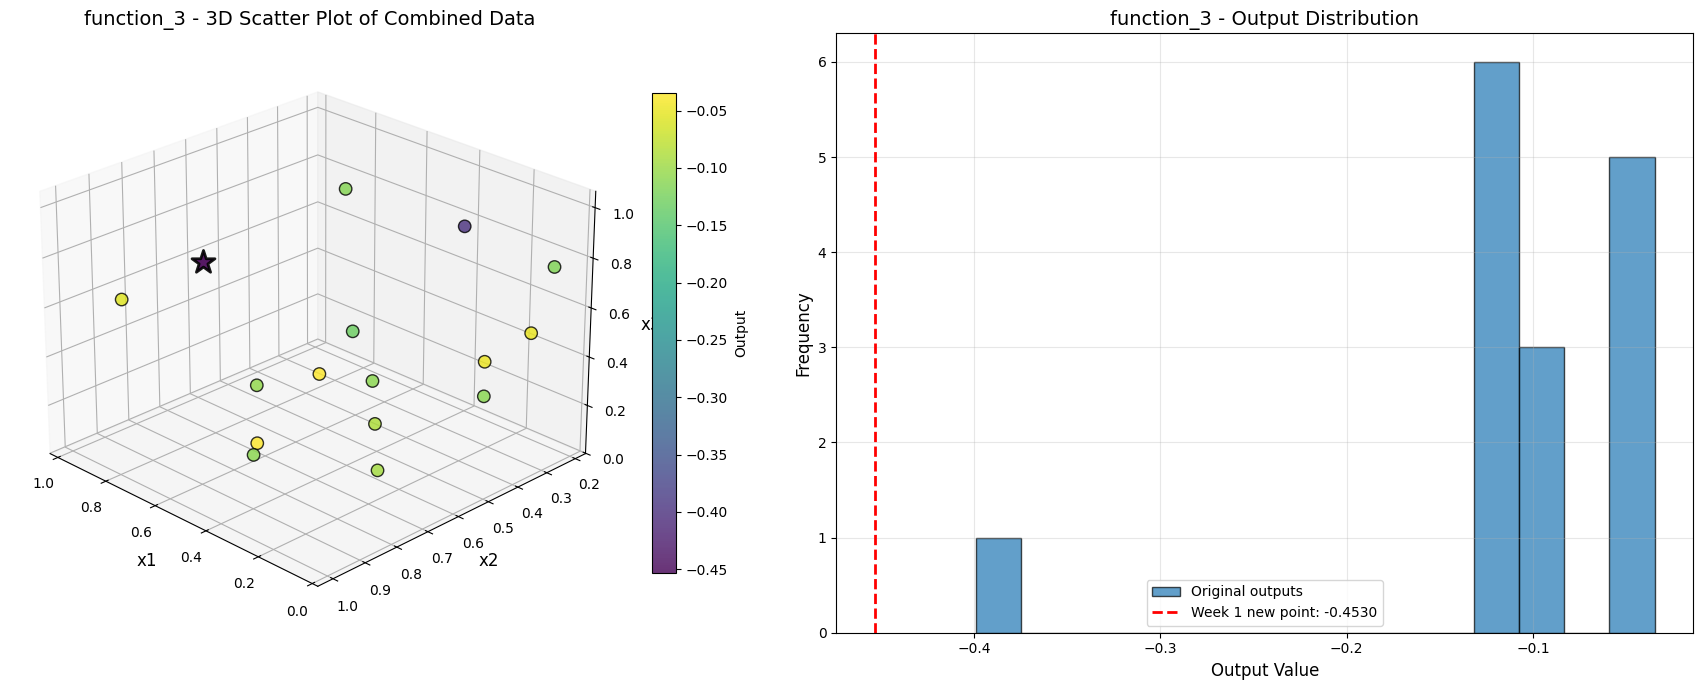


Combined inputs shape: (16, 3)
Combined outputs shape: (16,)


In [ ]:
# Function 3 - Visualization using utility function
function_name = 'function_3'
original_inputs = initial_data[function_name]['inputs']
original_outputs = initial_data[function_name]['outputs']
new_input = week1_data[function_name]['input']
new_output = week1_data[function_name]['output']

# Use utility function for visualization
plot_3d_scatter_with_distribution(
    original_inputs, original_outputs,
    new_input, new_output,
    function_name
)

# Print combined data info
combined_inputs, combined_outputs = combine_data(
    original_inputs, original_outputs, new_input, new_output
)
print(f"\nCombined inputs shape: {combined_inputs.shape}")
print(f"Combined outputs shape: {combined_outputs.shape}")


### FUNCTION 4 - COMBINED DATA AND VISUALISATION


In [ ]:
# Function 4 - Combine original data with week 1 data
function_name = 'function_4'

# Get original inputs and outputs
original_inputs = initial_data[function_name]['inputs']
original_outputs = initial_data[function_name]['outputs']

# Get week 1 new input and output
new_input = week1_data[function_name]['input']
new_output = week1_data[function_name]['output']

# Combine inputs: original + new (reshape new_input to be a row vector)
combined_inputs = np.vstack([original_inputs, new_input.reshape(1, -1)])

# Combine outputs: original + new
combined_outputs = np.concatenate([original_outputs, np.array([new_output])])

print("=" * 60)
print(f"FUNCTION 4 - COMBINED DATA")
print("=" * 60)
print(f"\nOriginal inputs shape: {original_inputs.shape}")
print(f"Original inputs:\n{original_inputs}")
print(f"\nNew input from week 1: {new_input}")
print(f"\nCombined inputs shape: {combined_inputs.shape}")
print(f"Combined inputs:\n{combined_inputs}")
print(f"\n" + "-" * 60)
print(f"\nOriginal outputs shape: {original_outputs.shape}")
print(f"Original outputs:\n{original_outputs}")
print(f"\nNew output from week 1: {new_output}")
print(f"\nCombined outputs shape: {combined_outputs.shape}")
print(f"Combined outputs:\n{combined_outputs}")
print("=" * 60)


FUNCTION 4 - COMBINED DATA

Original inputs shape: (30, 4)
Original inputs:
[[0.89698105 0.72562797 0.17540431 0.70169437]
 [0.8893564  0.49958786 0.53926886 0.50878344]
 [0.25094624 0.03369313 0.14538002 0.49493242]
 [0.34696206 0.0062504  0.76056361 0.61302356]
 [0.12487118 0.12977019 0.38440048 0.2870761 ]
 [0.80130271 0.50023109 0.70664456 0.19510284]
 [0.24770826 0.06044543 0.04218635 0.44132425]
 [0.74670224 0.7570915  0.36935306 0.20656628]
 [0.40066503 0.07257425 0.88676825 0.24384229]
 [0.6260706  0.58675126 0.43880578 0.77885769]
 [0.95713529 0.59764438 0.76611385 0.77620991]
 [0.73281243 0.14524998 0.47681272 0.13336573]
 [0.65511548 0.07239183 0.68715175 0.08151656]
 [0.21973443 0.83203134 0.48286416 0.08256923]
 [0.48859419 0.2119651  0.93917791 0.37619173]
 [0.16713049 0.87655456 0.21723954 0.95980098]
 [0.21691119 0.16608583 0.24137226 0.77006248]
 [0.38748784 0.80453226 0.75179548 0.72382744]
 [0.98562189 0.66693268 0.15678328 0.8565348 ]
 [0.03782483 0.66485335 0.16198

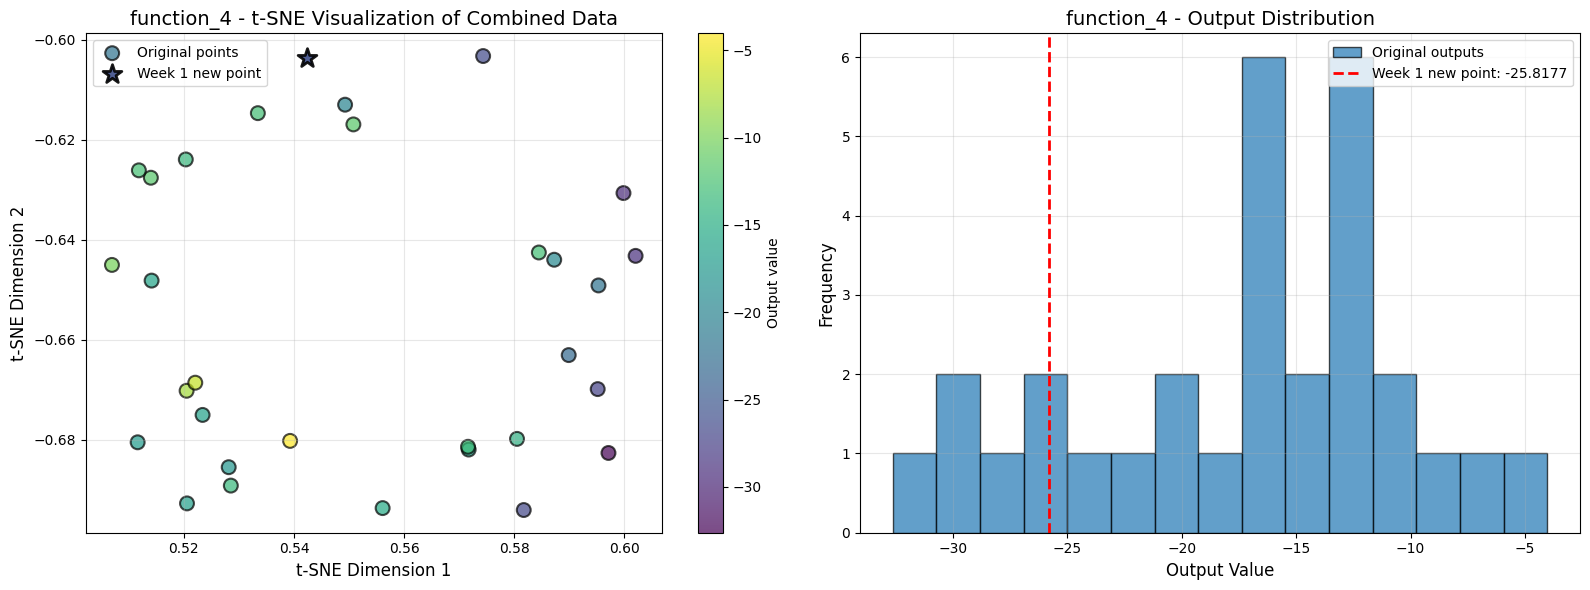


Combined inputs shape: (31, 4)
Combined outputs shape: (31,)


In [ ]:
# Function 4 - Visualization using utility function
function_name = 'function_4'
original_inputs = initial_data[function_name]['inputs']
original_outputs = initial_data[function_name]['outputs']
new_input = week1_data[function_name]['input']
new_output = week1_data[function_name]['output']

# Use utility function for visualization
plot_tsne_with_distribution(
    original_inputs, original_outputs,
    new_input, new_output,
    function_name
)

# Print combined data info
combined_inputs, combined_outputs = combine_data(
    original_inputs, original_outputs, new_input, new_output
)
print(f"\nCombined inputs shape: {combined_inputs.shape}")
print(f"Combined outputs shape: {combined_outputs.shape}")


### FUNCTION 5 - COMBINED DATA AND VISUALISATION


In [ ]:
# Function 5 - Combine original data with week 1 data
function_name = 'function_5'

# Get original inputs and outputs
original_inputs = initial_data[function_name]['inputs']
original_outputs = initial_data[function_name]['outputs']

# Get week 1 new input and output
new_input = week1_data[function_name]['input']
new_output = week1_data[function_name]['output']

# Combine inputs: original + new (reshape new_input to be a row vector)
combined_inputs = np.vstack([original_inputs, new_input.reshape(1, -1)])

# Combine outputs: original + new
combined_outputs = np.concatenate([original_outputs, np.array([new_output])])

print("=" * 60)
print(f"FUNCTION 5 - COMBINED DATA")
print("=" * 60)
print(f"\nOriginal inputs shape: {original_inputs.shape}")
print(f"Original inputs:\n{original_inputs}")
print(f"\nNew input from week 1: {new_input}")
print(f"\nCombined inputs shape: {combined_inputs.shape}")
print(f"Combined inputs:\n{combined_inputs}")
print(f"\n" + "-" * 60)
print(f"\nOriginal outputs shape: {original_outputs.shape}")
print(f"Original outputs:\n{original_outputs}")
print(f"\nNew output from week 1: {new_output}")
print(f"\nCombined outputs shape: {combined_outputs.shape}")
print(f"Combined outputs:\n{combined_outputs}")
print("=" * 60)


FUNCTION 5 - COMBINED DATA

Original inputs shape: (20, 4)
Original inputs:
[[0.19144708 0.03819337 0.60741781 0.41458414]
 [0.75865295 0.53651774 0.65600038 0.36034155]
 [0.43834987 0.8043397  0.21024527 0.15129482]
 [0.70605083 0.53419196 0.26424335 0.48208755]
 [0.83647799 0.19360965 0.6638927  0.78564888]
 [0.68343225 0.11866264 0.82904591 0.56757661]
 [0.55362148 0.66734998 0.32380582 0.81486975]
 [0.35235627 0.32224153 0.11697937 0.47311252]
 [0.15378571 0.72938169 0.42259844 0.44307417]
 [0.46344227 0.63002451 0.10790646 0.9576439 ]
 [0.67749115 0.35850951 0.47959222 0.07288048]
 [0.58397341 0.14724265 0.34809746 0.42861465]
 [0.30688872 0.31687813 0.62263448 0.09539906]
 [0.51114177 0.817957   0.72871042 0.11235362]
 [0.43893338 0.77409176 0.37816709 0.93369621]
 [0.22418902 0.84648049 0.87948418 0.87851568]
 [0.72526172 0.47987049 0.08894684 0.75976022]
 [0.35548161 0.63961937 0.41761768 0.12260384]
 [0.11987923 0.86254031 0.64333133 0.84980383]
 [0.12688467 0.15342962 0.77016

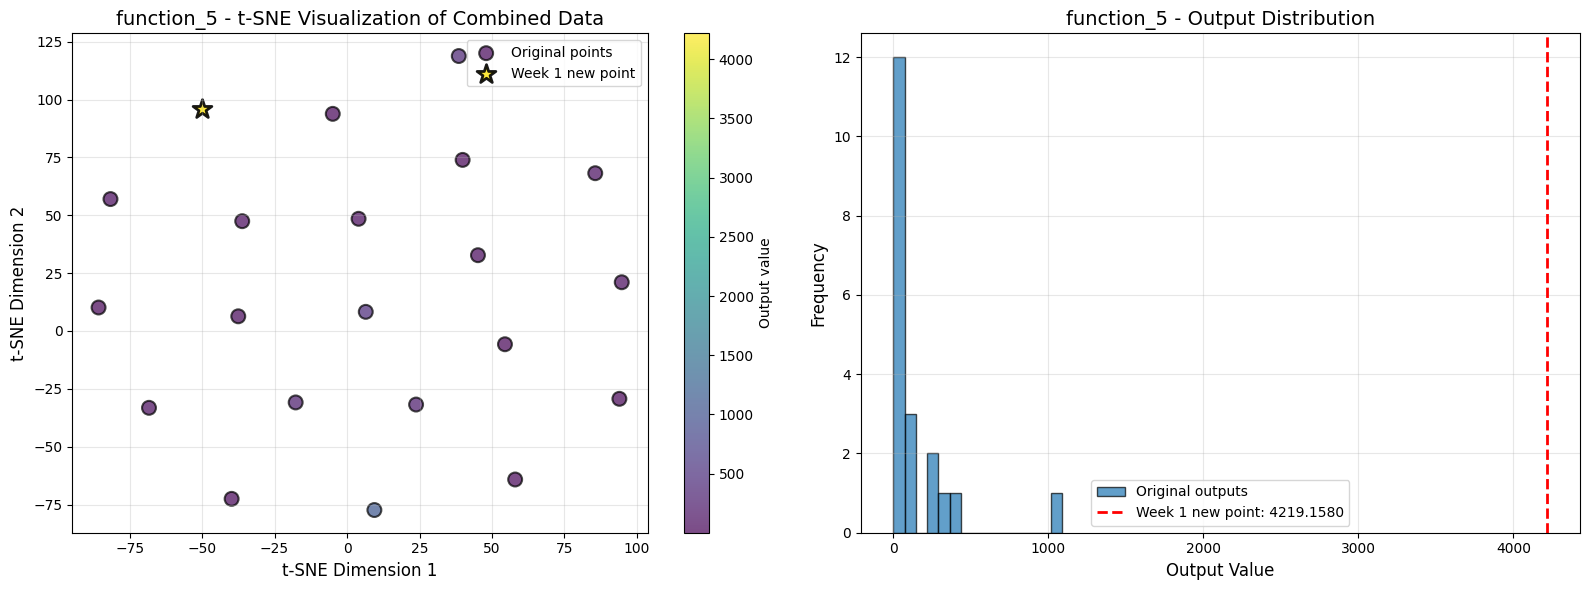


Combined inputs shape: (21, 4)
Combined outputs shape: (21,)


In [ ]:
# Function 5 - Visualization using utility function
function_name = 'function_5'
original_inputs = initial_data[function_name]['inputs']
original_outputs = initial_data[function_name]['outputs']
new_input = week1_data[function_name]['input']
new_output = week1_data[function_name]['output']

# Use utility function for visualization
plot_tsne_with_distribution(
    original_inputs, original_outputs,
    new_input, new_output,
    function_name
)

# Print combined data info
combined_inputs, combined_outputs = combine_data(
    original_inputs, original_outputs, new_input, new_output
)
print(f"\nCombined inputs shape: {combined_inputs.shape}")
print(f"Combined outputs shape: {combined_outputs.shape}")


### FUNCTION 6 - COMBINED DATA AND VISUALISATION


In [ ]:
# Function 6 - Combine original data with week 1 data
function_name = 'function_6'

# Get original inputs and outputs
original_inputs = initial_data[function_name]['inputs']
original_outputs = initial_data[function_name]['outputs']

# Get week 1 new input and output
new_input = week1_data[function_name]['input']
new_output = week1_data[function_name]['output']

# Combine inputs: original + new (reshape new_input to be a row vector)
combined_inputs = np.vstack([original_inputs, new_input.reshape(1, -1)])

# Combine outputs: original + new
combined_outputs = np.concatenate([original_outputs, np.array([new_output])])

print("=" * 60)
print(f"FUNCTION 6 - COMBINED DATA")
print("=" * 60)
print(f"\nOriginal inputs shape: {original_inputs.shape}")
print(f"Original inputs:\n{original_inputs}")
print(f"\nNew input from week 1: {new_input}")
print(f"\nCombined inputs shape: {combined_inputs.shape}")
print(f"Combined inputs:\n{combined_inputs}")
print(f"\n" + "-" * 60)
print(f"\nOriginal outputs shape: {original_outputs.shape}")
print(f"Original outputs:\n{original_outputs}")
print(f"\nNew output from week 1: {new_output}")
print(f"\nCombined outputs shape: {combined_outputs.shape}")
print(f"Combined outputs:\n{combined_outputs}")
print("=" * 60)


FUNCTION 6 - COMBINED DATA

Original inputs shape: (20, 5)
Original inputs:
[[0.7281861  0.15469257 0.73255167 0.69399651 0.05640131]
 [0.24238435 0.84409997 0.5778091  0.67902128 0.50195289]
 [0.72952261 0.7481062  0.67977464 0.35655228 0.67105368]
 [0.77062024 0.11440374 0.04677993 0.64832428 0.27354905]
 [0.6188123  0.33180214 0.18728787 0.75623847 0.3288348 ]
 [0.78495809 0.91068235 0.7081201  0.95922543 0.0049115 ]
 [0.14511079 0.8966846  0.89632223 0.72627154 0.23627199]
 [0.94506907 0.28845905 0.97880576 0.96165559 0.59801594]
 [0.12572016 0.86272469 0.02854433 0.24660527 0.75120624]
 [0.75759436 0.35583141 0.0165229  0.4342072  0.11243304]
 [0.5367969  0.30878091 0.41187929 0.38822518 0.5225283 ]
 [0.95773967 0.23566857 0.09914585 0.15680593 0.07131737]
 [0.6293079  0.80348368 0.81140844 0.04561319 0.11062446]
 [0.02173531 0.42808424 0.83593944 0.48948866 0.51108173]
 [0.43934426 0.69892383 0.42682022 0.10947609 0.87788847]
 [0.25890557 0.79367771 0.6421139  0.19667346 0.593103

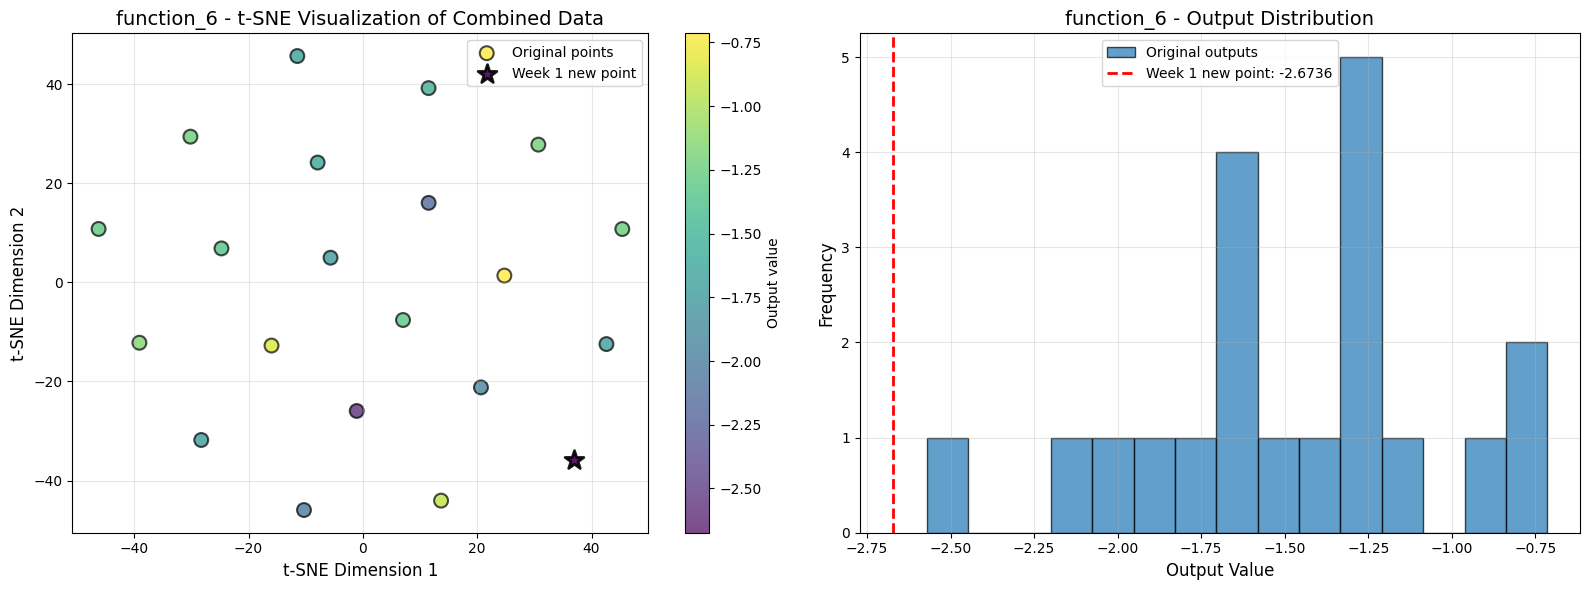


Combined inputs shape: (21, 5)
Combined outputs shape: (21,)


In [ ]:
# Function 6 - Visualization using utility function
function_name = 'function_6'
original_inputs = initial_data[function_name]['inputs']
original_outputs = initial_data[function_name]['outputs']
new_input = week1_data[function_name]['input']
new_output = week1_data[function_name]['output']

# Use utility function for visualization
plot_tsne_with_distribution(
    original_inputs, original_outputs,
    new_input, new_output,
    function_name
)

# Print combined data info
combined_inputs, combined_outputs = combine_data(
    original_inputs, original_outputs, new_input, new_output
)
print(f"\nCombined inputs shape: {combined_inputs.shape}")
print(f"Combined outputs shape: {combined_outputs.shape}")


### FUNCTION 7 - COMBINED DATA AND VISUALISATION


In [ ]:
# Function 7 - Combine original data with week 1 data
function_name = 'function_7'

# Get original inputs and outputs
original_inputs = initial_data[function_name]['inputs']
original_outputs = initial_data[function_name]['outputs']

# Get week 1 new input and output
new_input = week1_data[function_name]['input']
new_output = week1_data[function_name]['output']

# Combine inputs: original + new (reshape new_input to be a row vector)
combined_inputs = np.vstack([original_inputs, new_input.reshape(1, -1)])

# Combine outputs: original + new
combined_outputs = np.concatenate([original_outputs, np.array([new_output])])

print("=" * 60)
print(f"FUNCTION 7 - COMBINED DATA")
print("=" * 60)
print(f"\nOriginal inputs shape: {original_inputs.shape}")
print(f"Original inputs:\n{original_inputs}")
print(f"\nNew input from week 1: {new_input}")
print(f"\nCombined inputs shape: {combined_inputs.shape}")
print(f"Combined inputs:\n{combined_inputs}")
print(f"\n" + "-" * 60)
print(f"\nOriginal outputs shape: {original_outputs.shape}")
print(f"Original outputs:\n{original_outputs}")
print(f"\nNew output from week 1: {new_output}")
print(f"\nCombined outputs shape: {combined_outputs.shape}")
print(f"Combined outputs:\n{combined_outputs}")
print("=" * 60)


FUNCTION 7 - COMBINED DATA

Original inputs shape: (30, 6)
Original inputs:
[[0.27262382 0.32449536 0.89710881 0.83295115 0.15406269 0.79586362]
 [0.54300258 0.9246939  0.34156746 0.64648585 0.71844033 0.34313266]
 [0.09083225 0.66152938 0.06593091 0.25857701 0.96345285 0.6402654 ]
 [0.11886697 0.61505494 0.90581639 0.8553003  0.41363143 0.58523563]
 [0.63021764 0.8380969  0.68001305 0.73189509 0.52673671 0.34842921]
 [0.76491917 0.25588292 0.60908422 0.21807904 0.32294277 0.09579366]
 [0.05789554 0.49167222 0.24742222 0.21811844 0.42042833 0.73096984]
 [0.19525188 0.07922665 0.55458046 0.17056682 0.01494418 0.10703171]
 [0.64230298 0.83687455 0.02179269 0.10148801 0.68307083 0.6924164 ]
 [0.78994255 0.19554501 0.57562333 0.07365919 0.25904917 0.05109986]
 [0.52849733 0.45742436 0.36009569 0.36204551 0.81689098 0.63747637]
 [0.72261522 0.01181284 0.06364591 0.16517311 0.07924415 0.35995166]
 [0.07566492 0.33450212 0.13273274 0.60831236 0.91838592 0.82233079]
 [0.94245084 0.37743962 0.4

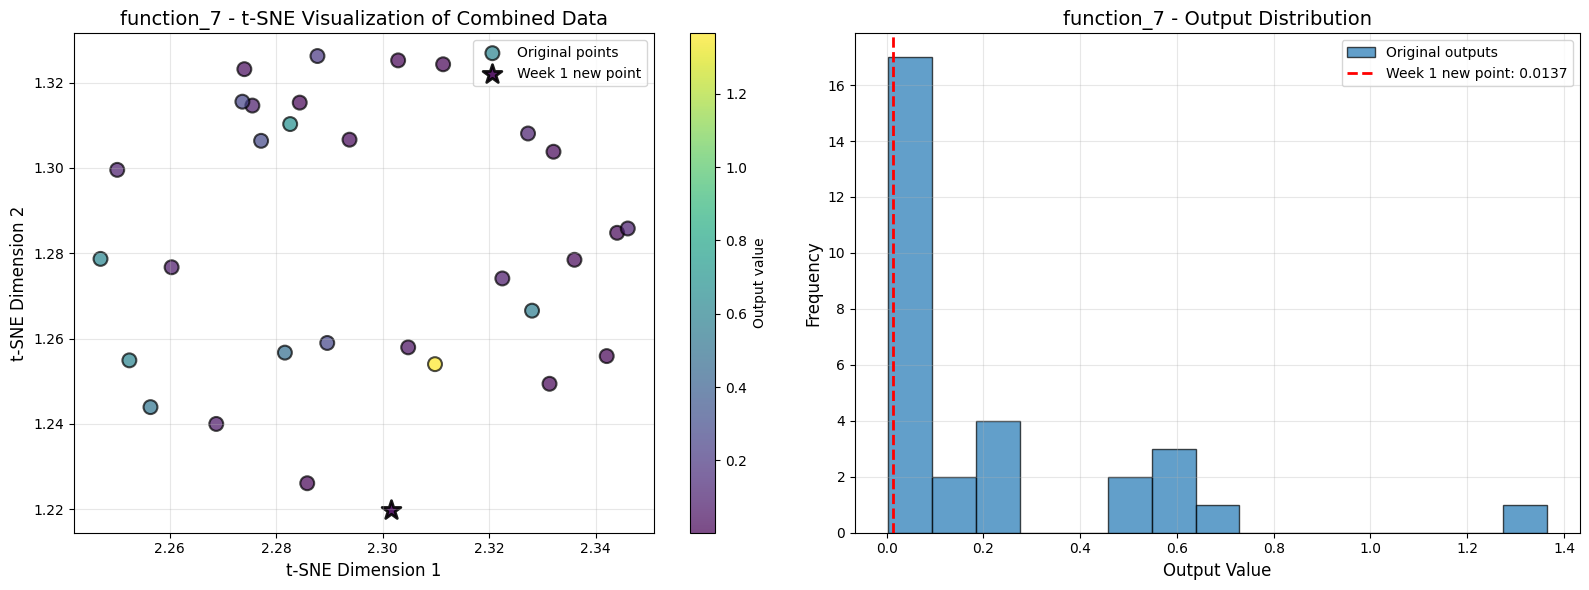


Combined inputs shape: (31, 6)
Combined outputs shape: (31,)


In [ ]:
# Function 7 - Visualization using utility function
function_name = 'function_7'
original_inputs = initial_data[function_name]['inputs']
original_outputs = initial_data[function_name]['outputs']
new_input = week1_data[function_name]['input']
new_output = week1_data[function_name]['output']

# Use utility function for visualization
plot_tsne_with_distribution(
    original_inputs, original_outputs,
    new_input, new_output,
    function_name
)

# Print combined data info
combined_inputs, combined_outputs = combine_data(
    original_inputs, original_outputs, new_input, new_output
)
print(f"\nCombined inputs shape: {combined_inputs.shape}")
print(f"Combined outputs shape: {combined_outputs.shape}")


### FUNCTION 8 - COMBINED DATA AND VISUALISATION


In [ ]:
# Function 8 - Combine original data with week 1 data
function_name = 'function_8'

# Get original inputs and outputs
original_inputs = initial_data[function_name]['inputs']
original_outputs = initial_data[function_name]['outputs']

# Get week 1 new input and output
new_input = week1_data[function_name]['input']
new_output = week1_data[function_name]['output']

# Combine inputs: original + new (reshape new_input to be a row vector)
combined_inputs = np.vstack([original_inputs, new_input.reshape(1, -1)])

# Combine outputs: original + new
combined_outputs = np.concatenate([original_outputs, np.array([new_output])])

print("=" * 60)
print(f"FUNCTION 8 - COMBINED DATA")
print("=" * 60)
print(f"\nOriginal inputs shape: {original_inputs.shape}")
print(f"Original inputs:\n{original_inputs}")
print(f"\nNew input from week 1: {new_input}")
print(f"\nCombined inputs shape: {combined_inputs.shape}")
print(f"Combined inputs:\n{combined_inputs}")
print(f"\n" + "-" * 60)
print(f"\nOriginal outputs shape: {original_outputs.shape}")
print(f"Original outputs:\n{original_outputs}")
print(f"\nNew output from week 1: {new_output}")
print(f"\nCombined outputs shape: {combined_outputs.shape}")
print(f"Combined outputs:\n{combined_outputs}")
print("=" * 60)


FUNCTION 8 - COMBINED DATA

Original inputs shape: (40, 8)
Original inputs:
[[0.60499445 0.29221502 0.90845275 0.35550624 0.20166872 0.57533801
  0.31031095 0.73428138]
 [0.17800696 0.56622265 0.99486184 0.21032501 0.32015266 0.70790879
  0.63538449 0.10713163]
 [0.00907698 0.81162615 0.52052036 0.07568668 0.26511183 0.09165169
  0.59241515 0.36732026]
 [0.50602816 0.65373012 0.36341078 0.17798105 0.0937283  0.19742533
  0.7558269  0.29247234]
 [0.35990926 0.24907568 0.49599717 0.70921498 0.11498719 0.28920692
  0.55729515 0.59388173]
 [0.77881834 0.0034195  0.33798313 0.51952778 0.82090699 0.53724669
  0.5513471  0.66003209]
 [0.90864932 0.0622497  0.23825955 0.76660355 0.13233596 0.99024381
  0.68806782 0.74249594]
 [0.58637144 0.88073573 0.74502075 0.54603485 0.00964888 0.74899176
  0.23090707 0.09791562]
 [0.76113733 0.85467239 0.38212433 0.33735198 0.68970832 0.30985305
  0.63137968 0.04195607]
 [0.9849332  0.69950626 0.9988855  0.18014846 0.58014315 0.23108719
  0.49082694 0.3136

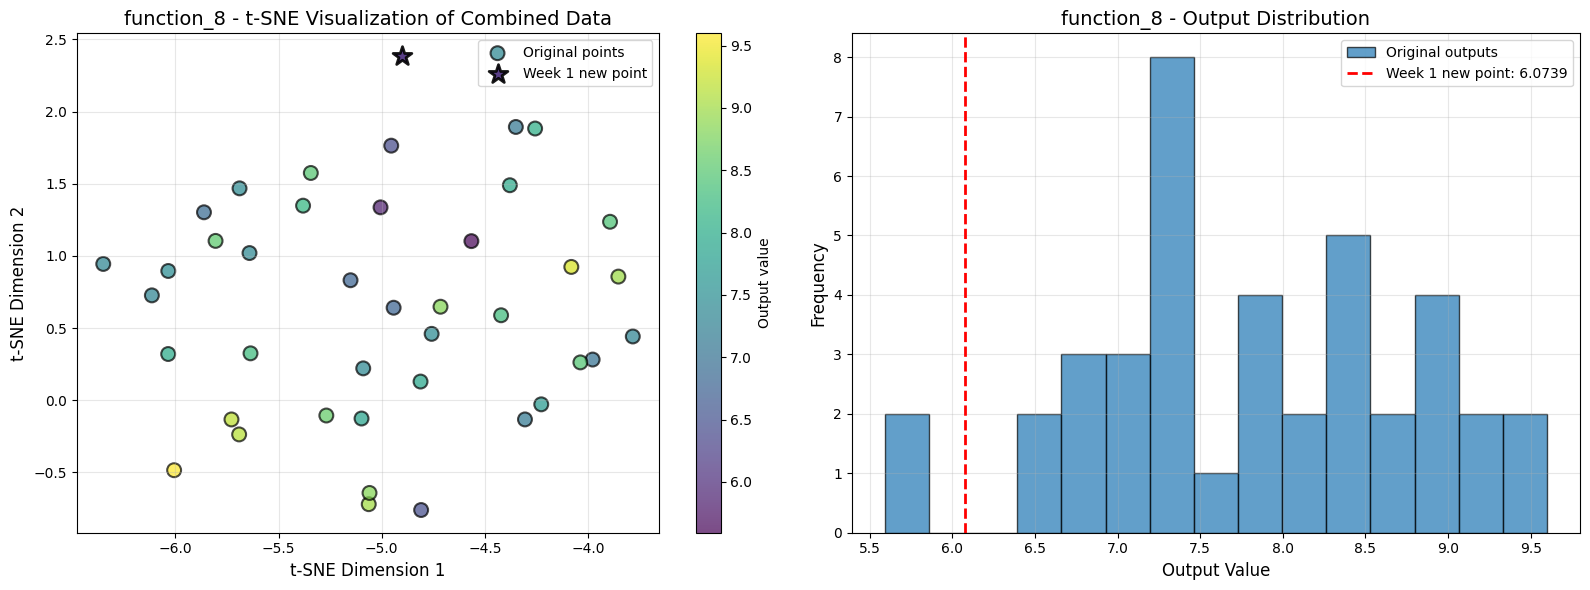


Combined inputs shape: (41, 8)
Combined outputs shape: (41,)


In [ ]:
# Function 8 - Visualization using utility function
function_name = 'function_8'
original_inputs = initial_data[function_name]['inputs']
original_outputs = initial_data[function_name]['outputs']
new_input = week1_data[function_name]['input']
new_output = week1_data[function_name]['output']

# Use utility function for visualization
plot_tsne_with_distribution(
    original_inputs, original_outputs,
    new_input, new_output,
    function_name
)

# Print combined data info
combined_inputs, combined_outputs = combine_data(
    original_inputs, original_outputs, new_input, new_output
)
print(f"\nCombined inputs shape: {combined_inputs.shape}")
print(f"Combined outputs shape: {combined_outputs.shape}")


### BAYESIAN OPTIMIZATION - GP + UCB

Apply simple Bayesian Optimization with Gaussian Process surrogate and Upper Confidence Bound (UCB) acquisition function to all functions.


In [ ]:
# Import the Bayesian Optimization module
from bayesian_optimization import SimpleBayesianOptimization


In [ ]:
# Prepare data for Bayesian Optimization
# We'll use the combined data (original + week 1) as our starting observations

bo_results = {}

for function_num in range(1, 9):
    function_name = f'function_{function_num}'
    
    # Get combined data
    original_inputs = initial_data[function_name]['inputs']
    original_outputs = initial_data[function_name]['outputs']
    new_input = week1_data[function_name]['input']
    new_output = week1_data[function_name]['output']
    
    # Combine all observed data
    X_observed = np.vstack([original_inputs, new_input.reshape(1, -1)])
    y_observed = np.concatenate([original_outputs, np.array([new_output])])
    
    # Define bounds (all functions have inputs in [0, 1])
    n_dims = X_observed.shape[1]
    bounds = [[0.0, 1.0]] * n_dims
    
    # Create BO object
    bo = SimpleBayesianOptimization(bounds=bounds, n_initial=0, random_state=42)
    
    # Fit GP to observed data
    bo.fit(X_observed, y_observed)
    
    # Store results
    bo_results[function_name] = {
        'bo': bo,
        'X_observed': X_observed,
        'y_observed': y_observed,
        'n_dims': n_dims
    }
    
    print(f"{function_name}: Fitted GP to {len(X_observed)} observations ({n_dims}D)")


function_1: Fitted GP to 11 observations (2D)
function_2: Fitted GP to 11 observations (2D)
function_3: Fitted GP to 16 observations (3D)
function_4: Fitted GP to 31 observations (4D)
function_5: Fitted GP to 21 observations (4D)
function_6: Fitted GP to 21 observations (5D)


/Users/jackdunning/Documents/Github/Capstone-Project-Imperial-College-London/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/jackdunning/Documents/Github/Capstone-Project-Imperial-College-London/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/jackdunning/Documents/Github/Capstone-Project-Imperial-College-London/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is clos

function_7: Fitted GP to 31 observations (6D)
function_8: Fitted GP to 41 observations (8D)


In [ ]:
# Suggest next points for all functions using UCB
next_points_bo = {}
ucb_values = {}

print("=" * 60)
print("BAYESIAN OPTIMIZATION - NEXT POINT SUGGESTIONS")
print("=" * 60)

for function_num in range(1, 9):
    function_name = f'function_{function_num}'
    bo = bo_results[function_name]['bo']
    
    # Suggest next point using UCB
    next_point = bo.suggest_next_point(beta=2.0)
    
    # Get UCB value at this point
    ucb_value = bo.acquisition_ucb(next_point.reshape(1, -1), beta=2.0)[0]
    
    next_points_bo[function_name] = next_point
    ucb_values[function_name] = ucb_value
    
    # Format point for display
    formatted_point = '-'.join([f'{x:.6f}' for x in next_point])
    
    print(f"\n{function_name}:")
    print(f"  Suggested point: {formatted_point}")
    print(f"  UCB value: {ucb_value:.6f}")

print("=" * 60)


BAYESIAN OPTIMIZATION - NEXT POINT SUGGESTIONS

function_1:
  Suggested point: 0.000000-0.000000
  UCB value: 0.000477

function_2:
  Suggested point: 0.839041-1.000000
  UCB value: 1.078175

function_3:
  Suggested point: 1.000000-0.000000-0.757830
  UCB value: 0.407583

function_4:
  Suggested point: 0.413267-0.391233-0.327773-0.428435
  UCB value: -0.095554

function_5:
  Suggested point: 0.922382-0.960497-0.963203-0.824728
  UCB value: 4224.606827

function_6:
  Suggested point: 0.000000-0.000000-0.084701-1.000000-0.000000
  UCB value: 2.523158

function_7:
  Suggested point: 0.030175-0.312148-0.354869-0.145624-0.344577-0.758289
  UCB value: 1.660106

function_8:
  Suggested point: 0.073701-0.126448-0.000000-0.000000-0.849435-0.405574-0.048621-0.028310
  UCB value: 10.680716


### SANITY CHECK - Visualize GP Predictions and UCB

Visualize the GP surrogate model and UCB acquisition function for a few example functions to sanity check the BO implementation.


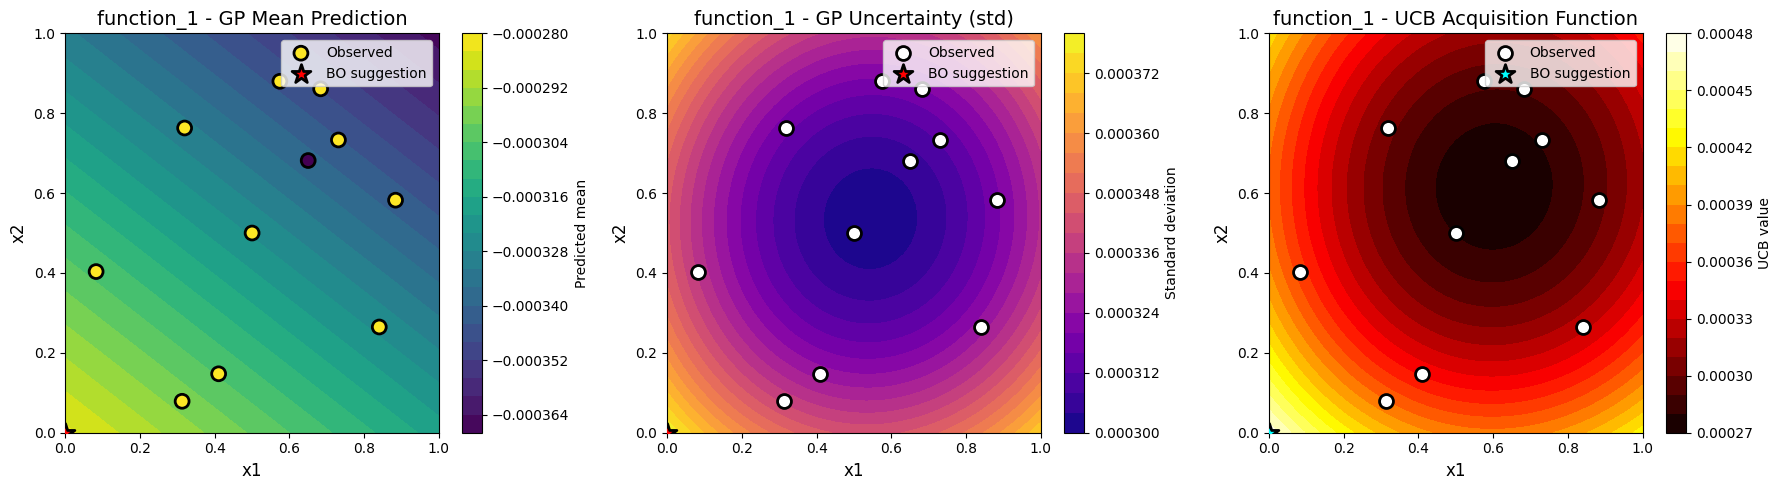


Function 1 BO Summary:
  Observed points: 11
  Best observed value: 0.000000
  Suggested next point: [0.000000, 0.000000]
  UCB value at suggestion: 0.000477


In [ ]:
# Sanity check: Visualize GP predictions for Function 1 (2D - easy to visualize)
function_name = 'function_1'
bo = bo_results[function_name]['bo']
X_obs = bo_results[function_name]['X_observed']
y_obs = bo_results[function_name]['y_observed']
next_point = next_points_bo[function_name]

# Use utility function for BO visualization
plot_bo_visualization_2d(bo, X_obs, y_obs, next_point, function_name)

print(f"\nFunction 1 BO Summary:")
print(f"  Observed points: {len(X_obs)}")
print(f"  Best observed value: {y_obs.max():.6f}")
print(f"  Suggested next point: [{next_point[0]:.6f}, {next_point[1]:.6f}]")
print(f"  UCB value at suggestion: {ucb_values[function_name]:.6f}")


NameError: name 'plot_function_summary_subplot' is not defined

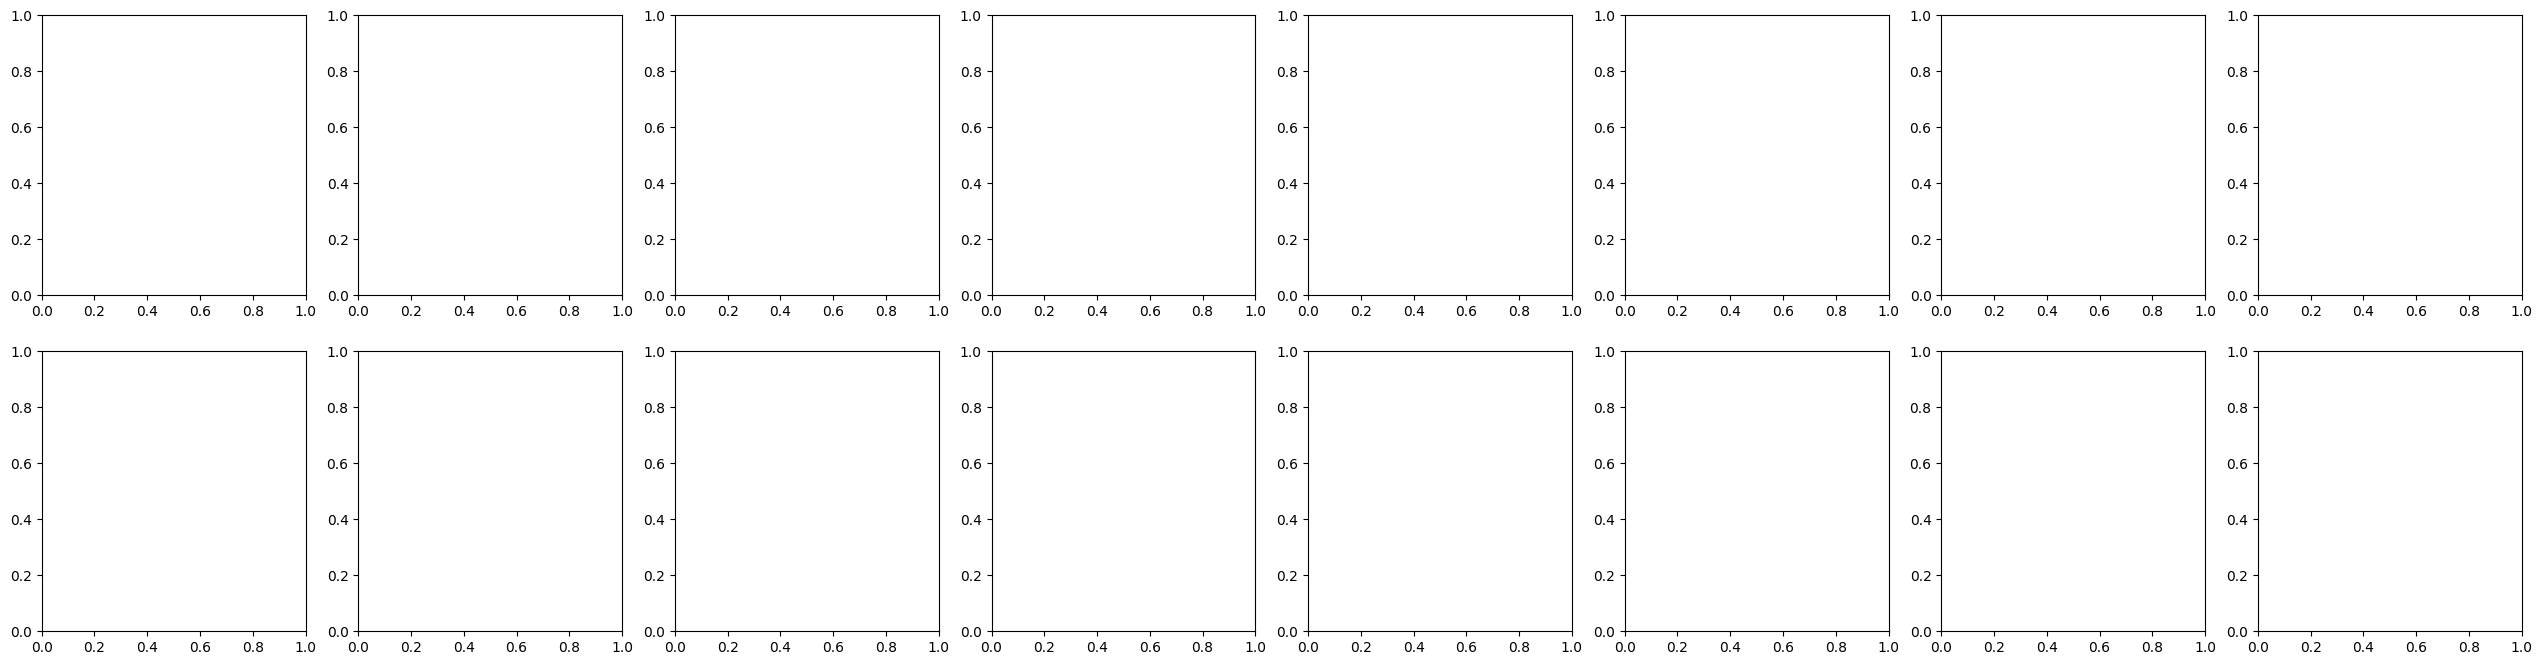

In [61]:
# Sanity check: Compare BO suggestions with observed data for all functions
# Using the same plot style as individual function visualizations

fig, axes = plt.subplots(2, 8, figsize=(32, 8))
axes = axes.flatten()

for idx, function_num in enumerate(range(1, 9)):
    function_name = f'function_{function_num}'
    
    # Get data
    original_inputs = initial_data[function_name]['inputs']
    original_outputs = initial_data[function_name]['outputs']
    week1_input = week1_data[function_name]['input']
    week1_output = week1_data[function_name]['output']
    bo_next_point = next_points_bo[function_name]
    n_dims = bo_results[function_name]['n_dims']
    
    # Get left and right axes for this function (2 subplots per function)
    ax_left = axes[idx * 2]
    ax_right = axes[idx * 2 + 1]
    
    # Use utility function to plot (same style as individual plots)
    plot_function_summary_subplot(
        ax_left, ax_right,
        original_inputs, original_outputs,
        week1_input, week1_output,
        bo_next_point,
        function_name, n_dims
    )

plt.tight_layout()
plt.show()

print("\nSummary: Colored stars show week 1 points, black stars show BO-suggested next points")
print("Each function shows input space visualization (left) and output distribution (right)")


In [54]:
# Print all BO suggestions in format ready for submission

print("=" * 60)
print("BAYESIAN OPTIMIZATION - NEXT POINTS FOR SUBMISSION")
print("=" * 60)
print("\nFormat: x1-x2-x3-... (one point per function)")
print()

for function_num in range(1, 9):
    function_name = f'function_{function_num}'
    next_point = next_points_bo[function_name]
    formatted_point = '-'.join([f'{x:.6f}' for x in next_point])
    print(f"{function_name}: {formatted_point}")

print()
print("=" * 60)


BAYESIAN OPTIMIZATION - NEXT POINTS FOR SUBMISSION

Format: x1-x2-x3-... (one point per function)

function_1: 0.000000-0.000000
function_2: 0.839041-1.000000
function_3: 1.000000-0.000000-0.757830
function_4: 0.413267-0.391233-0.327773-0.428435
function_5: 0.922382-0.960497-0.963203-0.824728
function_6: 0.000000-0.000000-0.084701-1.000000-0.000000
function_7: 0.030175-0.312148-0.354869-0.145624-0.344577-0.758289
function_8: 0.073701-0.126448-0.000000-0.000000-0.849435-0.405574-0.048621-0.028310

